In [130]:
import numpy as np
import glob
import lgdo.lh5 as lh5
import os, json
import copy
import glob
import matplotlib.pyplot as plt
from pygama.pargen.utils import load_data
from legendmeta import LegendMetadata
from dbetto import Props, TextDB, AttrsDict
import pandas as pd
from tqdm.notebook import tqdm
import awkward as ak
import polars as pl

from helper_lib import *
from resolution_extraction import weighted_resolution_from_nested_dict as wres_full
from resolution_extraction import weighted_resolution_per_detector as wres_det
from resolution_extraction import get_eres_per_detector

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
df = pl.read_parquet("data.parquet")
print(df)

shape: (77_705_036, 11)
┌─────────────┬─────────────┬─────────┬─────────────────┬───┬────────────┬────────┬─────┬───────┐
│ energy      ┆ energy_sum  ┆ hit_idx ┆ is_good_channel ┆ … ┆ evtid      ┆ period ┆ run ┆ sim_e │
│ ---         ┆ ---         ┆ ---     ┆ ---             ┆   ┆ ---        ┆ ---    ┆ --- ┆ ---   │
│ f64         ┆ f64         ┆ i64     ┆ bool            ┆   ┆ f64        ┆ f64    ┆ f64 ┆ i64   │
╞═════════════╪═════════════╪═════════╪═════════════════╪═══╪════════════╪════════╪═════╪═══════╡
│ 199.774142  ┆ 199.774142  ┆ 0       ┆ true            ┆ … ┆ 0.0        ┆ 3.0    ┆ 0.0 ┆ 200   │
│ 200.157679  ┆ 200.157679  ┆ 0       ┆ true            ┆ … ┆ 3.0        ┆ 3.0    ┆ 0.0 ┆ 200   │
│ 200.132685  ┆ 200.132685  ┆ 0       ┆ true            ┆ … ┆ 4.0        ┆ 3.0    ┆ 0.0 ┆ 200   │
│ 199.554582  ┆ 199.554582  ┆ 0       ┆ true            ┆ … ┆ 5.0        ┆ 3.0    ┆ 0.0 ┆ 200   │
│ 199.286528  ┆ 199.286528  ┆ 0       ┆ true            ┆ … ┆ 6.0        ┆ 3.0    ┆ 0.0 ┆ 200 

In [12]:
scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"


In [ ]:
periods_dict = f"{scratch_folder}/generated/pars/detector_usabilities.yaml"

In [13]:
pars = Props.read_from("/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/v2.1.0/generated/par/pht/cal/p03/r000/l200-p03-r000-cal-20230311T235840Z-par_pht.json")

In [18]:
version = "v2.1.5"
base = f"/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/{version}/"
config = Props.read_from(base+"/config.json", subst_pathvar=True)['setups']['l200']['paths']

scratch_folder = "/pscratch/sd/b/borrfran/sim-v1.1.0-20260401/"

meta = LegendMetadata(config['metadata'])

timestamp = meta.dataprod.runinfo.p03.r000.phy.start_key

chmap = meta.channelmap(timestamp)


In [48]:
config['metadata']

'/global/cfs/projectdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/v2.1.5/inputs'

In [68]:
meta2 = LegendMetadata("./legend-metadata")

could not scan file /global/cfs/cdirs/m2676/users/borrfran/bosonic-DM/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f78ce2f0d10>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f78ce2f1120>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/bosonic-DM/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f78ce2f1170>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f78ce2f16c0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/bosonic-DM/legend-metadata/jldataprod/config/evt/p14_r0%%_evt_phy_overwrite.yaml, reason: ParserError('while parsing a block mapping', <yaml._yaml.Mark object at 0x7f78ce118400>, 'did not find expected key', <yaml._yaml.Mark object at 0x7f78ce1188b0>)
could not scan file /global/cfs/cdirs/m2676/users/borrfran/bosonic-

In [66]:
!ls /global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/

auto  ref  tmp


In [19]:
chmap['V02160A'].daq.rawid

1104000

In [85]:
def expand_range(item):
    if ".." not in item:
        return [item]  # già atomico
    start, end = item.split("..")
    
    prefix = start[0]          # 'r'
    s = int(start[1:])
    e = int(end[1:])
    width = len(start) - 1     # numero di cifre (es. 3)

    return [f"{prefix}{i:0{width}d}" for i in range(s, e + 1)]

In [119]:
periods_simulated = ['p03', 'p04', 'p06', 'p07', 'p08', 'p09']
periods_metadata = meta2.datasets.runlists['valid']['phy']

periods_dict = {
    k: [item for rng in v for item in expand_range(rng)]
    for k, v in periods_metadata.items()
}

keys = list(periods_dict.keys())
for key in keys:
    if key not in periods_simulated:
        periods_dict.pop(key)

periods_dict['p09'].remove('r004')

In [123]:
eres_dict = get_eres_per_detector(meta2, config, periods_dict)
Props.write_to("./v1/dictionaries/eres_dict.yaml", eres_dict)

p09-r005: 100%|██████████| 101/101 [00:00<00:00, 3903.98it/s]


In [133]:
eres_dict = tst

In [141]:
simulated_energies = range(200, 1100, 100)
res_per_det_tot = {}

for ene in tqdm(simulated_energies):
    
    res_per_det_tot[ene] = wres_det(eres_dict, ene)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

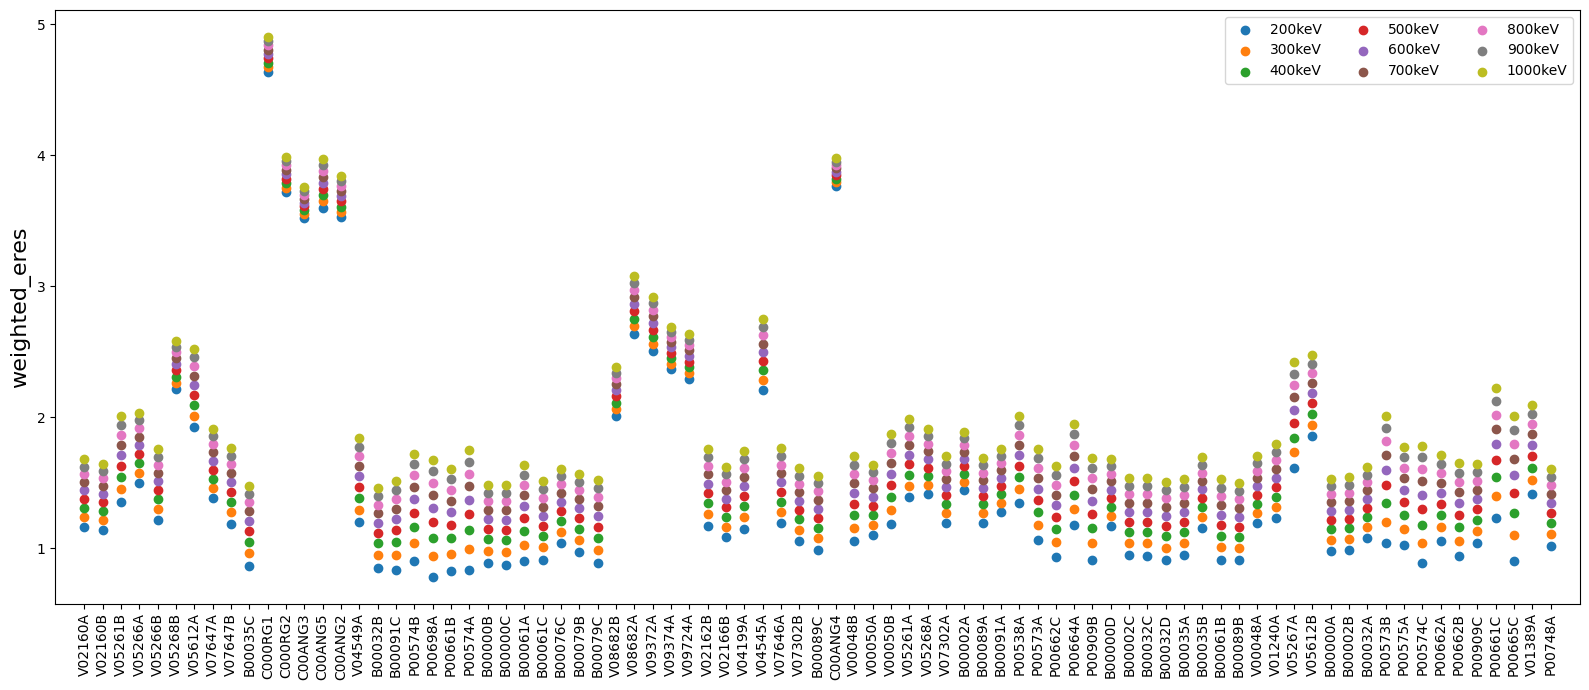

In [143]:
fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

for ene in tqdm(simulated_energies):
    
    keys, values = res_per_det_tot[ene].keys(), res_per_det_tot[ene].values()
    tag = f'{ene}keV'
    ax.scatter(keys, values, marker = 'o', label=tag)


plt.xticks(ticks=range(len(keys)), labels=keys, rotation=90, ha='center')

ax.set_ylabel(r"weighted_eres", fontsize = 16)
ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
plt.legend(ncol = 3)
# Padding sotto per non tagliare le etichette
plt.tight_layout()
plt.savefig("./plots/weighted_eres_per_energy.png", dpi=500)
plt.show()


In [144]:
eres = {}

for ene in tqdm(simulated_energies):
    
     eres[ene] = wres_full(eres_dict, ene)

  0%|          | 0/9 [00:00<?, ?it/s]

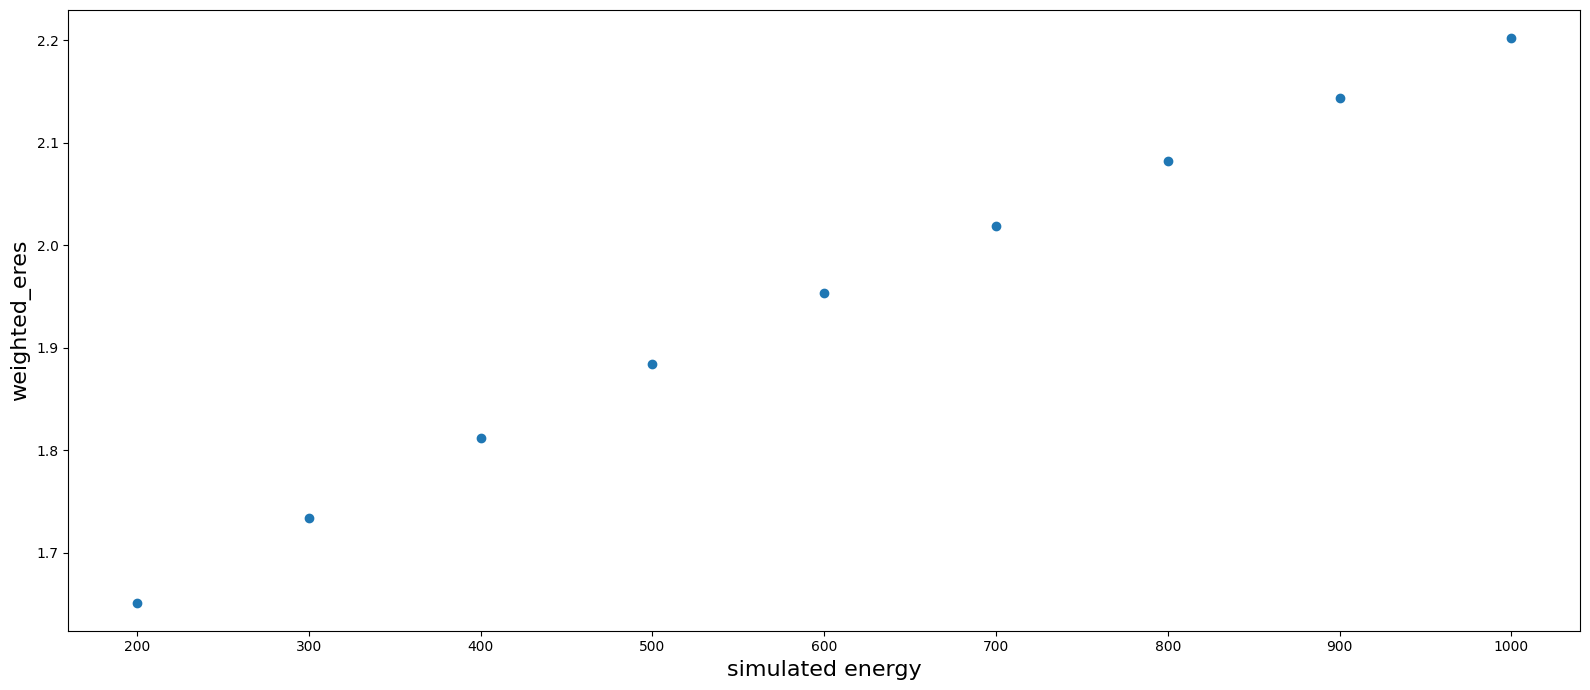

In [146]:
fig, ax = plt.subplots(figsize=(16, 7))  # larghezza generosa per spaziatura

keys, values = eres.keys(), eres.values()

ax.scatter(keys, values, marker = 'o')

ax.set_xlabel(r"simulated energy", fontsize = 16)
ax.set_ylabel(r"weighted_eres", fontsize = 16)
# ax.margins(x=0.02)  # riduce il padding laterale (default è 0.05)
# ax.set_ylim(0.75, 1)
# Padding sotto per non tagliare le etichette
plt.tight_layout()
plt.savefig("./plots/weighted_eres.png", dpi=500)
plt.show()
